In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

In [2]:
# reading csv file
df=pd.read_csv("/kaggle/input/datasets/amitabhajoy/bengaluru-house-price-data/Bengaluru_House_Data.csv")
df.info()
print(df.describe().T)
#df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB
           count        mean         std  min   25%   50%    75%     max
bath     13247.0    2.692610    1.341458  1.0   2.0   2.0    3.0    40.0
balcony  12711.0    1.584376    0.817263  0.0   1.0   2.0    2.0     3.0
price    13320.0  112.565627  148.971674  8.0  50.0  72.0  120.0  3600.0


### there are 13320 rows
### there are 9 columns
### area_type-availability-location-size-society-total_sqft ---> object
### bath-balcony-price---->numirical


In [3]:
# check null percentage 
df.isna().sum().sort_values()/len(df)*100

area_type        0.000000
availability     0.000000
total_sqft       0.000000
price            0.000000
location         0.007508
size             0.120120
bath             0.548048
balcony          4.572072
society         41.306306
dtype: float64

## dealing with null values

In [4]:
# Drop 'society' column due to high number of missing values or lack of predictive power
df_2 = df.drop(["society"], axis="columns").copy()

# Remove rows where critical information (location, size, bath) is missing
df_2 = df_2.dropna(subset=["location", "size", "bath"])

# Fill missing balcony values with the median to maintain distribution and avoid bias
df_2["balcony"] = df_2["balcony"].fillna(df_2["balcony"].median())

# Calculate and display the percentage of remaining missing values for quality check
(df_2.isna().sum().sort_values() / len(df_2)) * 100

area_type       0.0
availability    0.0
location        0.0
size            0.0
total_sqft      0.0
bath            0.0
balcony         0.0
price           0.0
dtype: float64

In [5]:
# Define a helper function to check if a value can be converted to float
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

# Identify and display rows where 'total_sqft' is not a valid numerical value
# This helps in detecting inconsistent formats like ranges (e.g., '1100 - 1500')
df_2[~df_2['total_sqft'].apply(is_float)].head(10)

,area_type,availability,location,size,total_sqft,bath,balcony,price
30,Super built-up Area,19-Dec,Yelahanka,4 BHK,2100 - 2850,4.0,0.0,186.000
122,Super built-up Area,18-Mar,Hebbal,4 BHK,3067 - 8156,4.0,0.0,477.000
137,Super built-up Area,19-Mar,8th Phase JP Nagar,2 BHK,1042 - 1105,2.0,0.0,54.005
165,Super built-up Area,18-Dec,Sarjapur,2 BHK,1145 - 1340,2.0,0.0,43.490
188,Super built-up Area,Ready To Move,KR Puram,2 BHK,1015 - 1540,2.0,0.0,56.800
410,Super built-up Area,Ready To Move,Kengeri,1 BHK,34.46Sq. Meter,1.0,0.0,18.500
549,Super built-up Area,18-Sep,Hennur Road,2 BHK,1195 - 1440,2.0,0.0,63.770
648,Built-up Area,Ready To Move,Arekere,9 Bedroom,4125Perch,9.0,2.0,265.000
661,Super built-up Area,Ready To Move,Yelahanka,2 BHK,1120 - 1145,2.0,0.0,48.130
672,Built-up Area,18-Mar,Bettahalsoor,4 Bedroom,3090 - 5002,4.0,0.0,445.000


In [6]:
# Convert square footage ranges (e.g., '1000 - 1200') into their average value
def convert_sqft(x):
    y=x.split("-")
    if len(y)==2:
        return (float(y[0])+float(y[1]))/2
    try:
        return float(x)
    except:
        return None

# Apply the conversion and remove any rows where conversion failed (None values)
df_2['total_sqft']=df_2['total_sqft'].apply(convert_sqft)

df_2=df_2.dropna(subset=["total_sqft"])

# Final check for missing values to ensure data integrity
(df_2.isna().sum().sort_values()/len(df_2))*100

# Extract numerical value from 'size' (e.g., '3 BHK' -> 3.0)
def conver_size(x):
    y=x.split()
    return float(y[0])
df_2["size"]=df_2["size"].apply(conver_size)

df_2.info()
print(df_2.describe().T)

<class 'pandas.core.frame.DataFrame'>
Index: 13200 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13200 non-null  object 
 1   availability  13200 non-null  object 
 2   location      13200 non-null  object 
 3   size          13200 non-null  float64
 4   total_sqft    13200 non-null  float64
 5   bath          13200 non-null  float64
 6   balcony       13200 non-null  float64
 7   price         13200 non-null  float64
dtypes: float64(5), object(3)
memory usage: 928.1+ KB
              count         mean          std  min     25%      50%     75%  \
size        13200.0     2.800833     1.292843  1.0     2.0     3.00     3.0   
total_sqft  13200.0  1555.302783  1237.323445  1.0  1100.0  1275.00  1672.0   
bath        13200.0     2.691136     1.338915  1.0     2.0     2.00     3.0   
balcony     13200.0     1.602348     0.804268  0.0     1.0     2.00     2.0   
price       13200.

## Univariate Analysis

Text(0.5, 1.0, 'boxplot of house price')

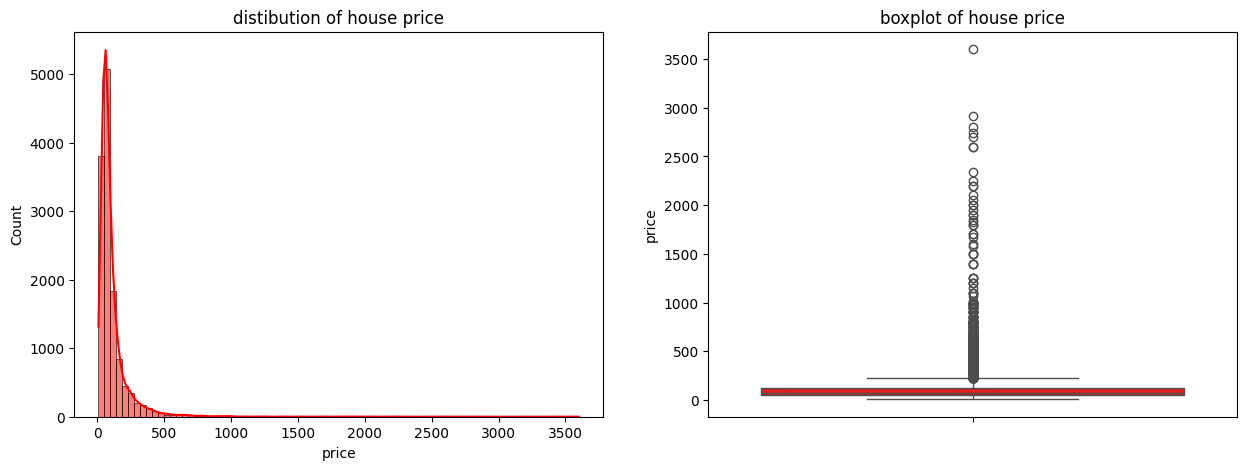

In [7]:
##Univariate Analysis
# most important is Target
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.histplot(df_2["price"],kde=True,color="red",bins=80)
plt.title("distibution of house price")

plt.subplot(1,2,2)
sns.boxplot(df_2["price"],color="red")
plt.title("boxplot of house price")


### house price---> right skew---->(alot outlires above 500)

array([[<Axes: title={'center': 'size'}>,
        <Axes: title={'center': 'total_sqft'}>],
       [<Axes: title={'center': 'bath'}>,
        <Axes: title={'center': 'balcony'}>],
       [<Axes: title={'center': 'price'}>, <Axes: >]], dtype=object)

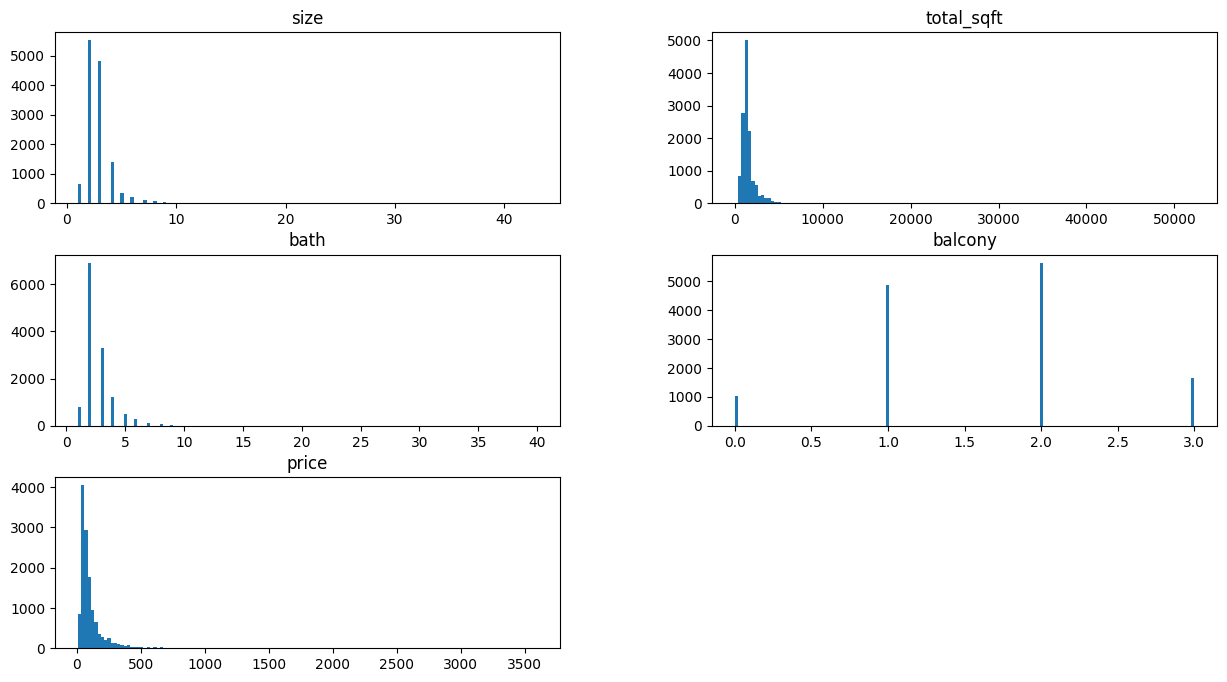

In [8]:
#Univariate Analysis for numrical data (histplot)
df_2.hist(figsize=(15,8),bins=140,grid=False)

Text(0.5, 1.0, 'balcony')

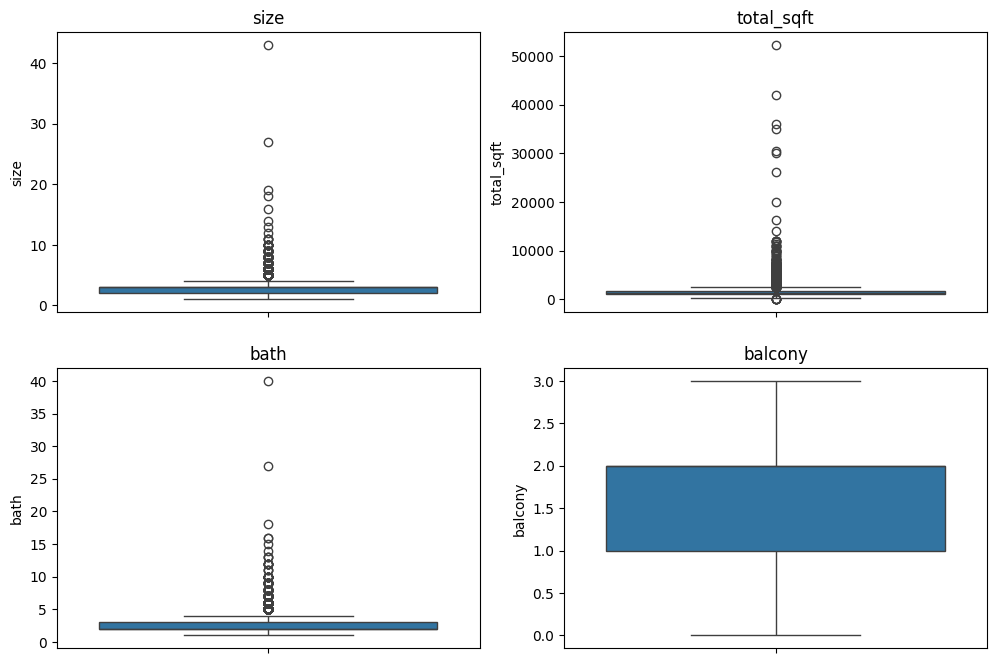

In [9]:
#Univariate Analysis for numrical data (boxplot)
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
sns.boxplot(df_2["size"])
plt.title("size")

plt.subplot(2,2,2)
sns.boxplot(df_2["total_sqft"])
plt.title("total_sqft")

plt.subplot(2,2,3)
sns.boxplot(df_2["bath"])
plt.title("bath")

plt.subplot(2,2,4)
sns.boxplot(df_2["balcony"])
plt.title("balcony")

### size---> may normal distribution --->there are outliers above 5
### total_sqft----> may need log scale---> alot outliers above 1400
### bath---> may need log scale ---> there are outlires above 6
### balcony----> may normal distribution--->no outliers

<Axes: xlabel='location', ylabel='count'>

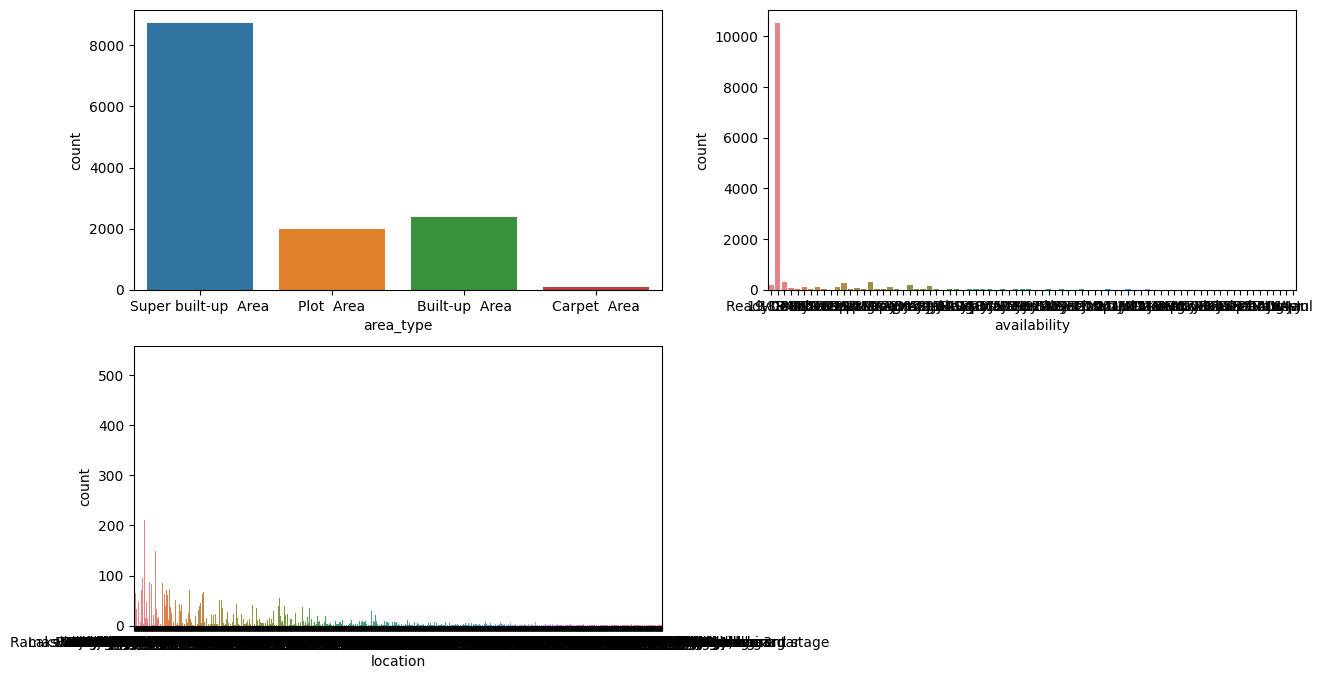

In [10]:
#Univariate Analysis for cateogrical data (countplot)
plt.figure(figsize=(15,8))
plt.subplot(2,2,1)
sns.countplot(data=df_2,x=df_2["area_type"],hue=df_2["area_type"])
plt.subplot(2,2,2)
sns.countplot(data=df_2,x=df_2["availability"],hue=df_2["availability"])
plt.subplot(2,2,3)
sns.countplot(data=df_2,x=df_2["location"],hue=df_2["location"])

### area_type --->most data is "super" so we can delete it now for simplification
### availability----> most data is "ready to move" so it will not change in model if i delete this data
### location-----> very important so we can make group of unique locations together

In [11]:
print("number of locations before grouping:", len(df_2["location"].unique()))

# Group rare locations into 'other' to reduce dimensionality for One-Hot Encoding
locations_col=df_2['location'].value_counts()
locations_less_10=locations_col[locations_col<10]
df_2["location"] = df_2["location"].apply(lambda x: 'other' if x in locations_less_10 else x)
print("number of locations after grouping:", len(df_2["location"].unique()))

number of locations before grouping: 1298
number of locations after grouping: 254


## Bivariate Analysis

In [12]:
## Bivariate Analysis

#df_2=df_2.drop(["area_type","availability","location"],axis="columns")
#df_2.corr()

### high positive corr between (size & bath )
### positive corr between (price & total_sqft)
### positive corr between (price & bath)

## dealing with outlier 

In [13]:
# Remove outliers: keep only properties with at least 300 sqft per bedroom (industry standard)
df_2=df_2[~(df_2["total_sqft"]/df_2["size"]<300)]

# Remove extreme outliers: filter out properties with more than 10 bedrooms
df_2=df_2[(df_2["size"]<10)]

# Filter out anomalies: remove properties where the number of bathrooms is unrealistically high compared to bedrooms
df_2=df_2[~(df_2["bath"]> (df_2["size"]+2))]

# Feature Engineering: create 'price_per_sqft' to help in identifying and removing price outliers
df_2['price_per_sqft'] = (df_2['price'] * 100000) / df_2['total_sqft']
df_2

,area_type,availability,location,size,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2.0,1056.0,2.0,1.0,39.07,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4.0,2600.0,5.0,3.0,120.00,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3.0,1440.0,2.0,3.0,62.00,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3.0,1521.0,3.0,1.0,95.00,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2.0,1200.0,2.0,1.0,51.00,4250.000000
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5.0,3453.0,4.0,0.0,231.00,6689.834926
13316,Super built-up Area,Ready To Move,other,4.0,3600.0,5.0,2.0,400.00,11111.111111
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2.0,1141.0,2.0,1.0,60.00,5258.545136
13318,Super built-up Area,18-Jun,Padmanabhanagar,4.0,4689.0,4.0,1.0,488.00,10407.336319


In [14]:
# Function to remove outliers based on 'price_per_sqft' within each location.
# It keeps only properties within 1 standard deviation of the location's mean price.
def remove_pps_outliers(df):
    df_0=pd.DataFrame()
    
    # Group data by location to apply filtering locally per neighborhood
    for key,subdf in df.groupby("location"):
        m= np.mean(subdf["price_per_sqft"])
        st= np.std(subdf["price_per_sqft"])

    # Filter properties: keep only those within [mean - std, mean + std]
        filter_pps=subdf[((subdf["price_per_sqft"]>(m-st)) & (subdf["price_per_sqft"]<(m+st)))]
        df_0= pd.concat([df_0,filter_pps],ignore_index=True)
    return df_0

df_3= remove_pps_outliers(df_2).copy()
df_3

,area_type,availability,location,size,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,18-May,Devarachikkanahalli,3.0,1250.0,2.0,3.0,44.00,3520.000000
1,Super built-up Area,Ready To Move,Devarachikkanahalli,2.0,1250.0,2.0,2.0,40.00,3200.000000
2,Plot Area,Ready To Move,Devarachikkanahalli,2.0,1200.0,2.0,2.0,83.00,6916.666667
3,Super built-up Area,Ready To Move,Devarachikkanahalli,2.0,1170.0,2.0,2.0,40.00,3418.803419
4,Super built-up Area,Ready To Move,Devarachikkanahalli,3.0,1425.0,2.0,2.0,65.00,4561.403509
...,...,...,...,...,...,...,...,...,...
10193,Super built-up Area,Ready To Move,other,2.0,1353.0,2.0,2.0,110.00,8130.081301
10194,Plot Area,18-Jan,other,1.0,812.0,1.0,0.0,26.00,3201.970443
10195,Super built-up Area,18-Jul,other,3.0,1440.0,2.0,2.0,63.93,4439.583333
10196,Super built-up Area,Ready To Move,other,2.0,1075.0,2.0,2.0,48.00,4465.116279


<Axes: xlabel='price', ylabel='Count'>

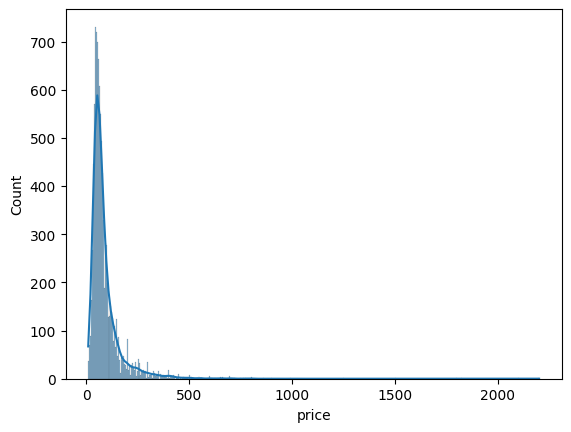

In [15]:
#check plot after filter
sns.histplot(df_3["price"],kde=True)


<Axes: xlabel='price', ylabel='Count'>

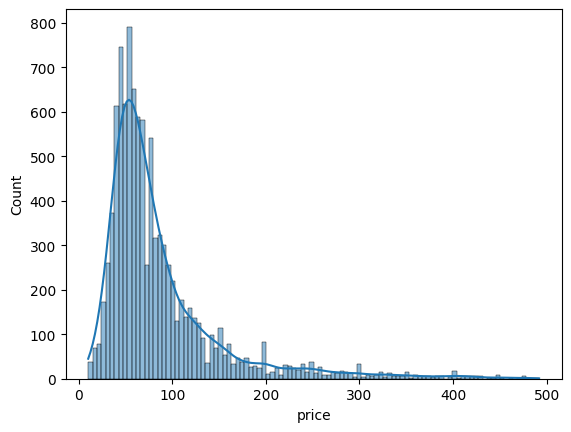

In [16]:
df_4=(df_3[df_3["price"]<500]).copy()
sns.histplot(df_4["price"],kde=True)

In [17]:
# drop features who have low predictive power for price in this dataset
df_4= df_4.drop(["area_type","availability","price_per_sqft"],axis="columns")

## Data Encoding

In [18]:
# Apply One-Hot Encoding to the 'location' categorical variable.
df_final=pd.get_dummies(df_4,columns=["location"],drop_first=True)
df_final

,size,total_sqft,bath,balcony,price,location_1st Block Jayanagar,location_1st Block Koramangala,location_1st Phase JP Nagar,location_2nd Phase Judicial Layout,location_2nd Stage Nagarbhavi,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
0,3.0,1250.0,2.0,3.0,44.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2.0,1250.0,2.0,2.0,40.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2.0,1200.0,2.0,2.0,83.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2.0,1170.0,2.0,2.0,40.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,3.0,1425.0,2.0,2.0,65.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10193,2.0,1353.0,2.0,2.0,110.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10194,1.0,812.0,1.0,0.0,26.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10195,3.0,1440.0,2.0,2.0,63.93,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10196,2.0,1075.0,2.0,2.0,48.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


# Model

## train test split

In [19]:
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score,KFold

X=df_final.drop(["price"], axis="columns")
y=df_final["price"]
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)


## linear_reg

In [20]:
from sklearn.linear_model import LinearRegression

reg_model=LinearRegression()
reg_model.fit(X_train,y_train)
print("score: ",reg_model.score(X_test,y_test))


score:  0.7618693232662774


In [21]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score,GridSearchCV,KFold

# Create a pipeline to scale features and apply the regression model
# This ensures scaling is only fitted on training data to prevent leakage
pip=Pipeline([
                ("scale",StandardScaler()),
                ("Ridge",Ridge())
])

param_grid= {
                "Ridge__alpha":[0.1,1,10,100]
}

Cv_stratgy=KFold(n_splits=5, random_state=42, shuffle=True)
grid_Ridge= GridSearchCV(pip, param_grid, cv=Cv_stratgy, scoring="r2")
grid_Ridge.fit(X_train,y_train)
print("best param: ",grid_Ridge.best_params_)
print("best score: ",grid_Ridge.best_score_)

best param:  {'Ridge__alpha': 100}
best score:  0.7991820118585524


In [22]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score,GridSearchCV,KFold
pip=Pipeline([
                ("scale",StandardScaler()),
                ("Lasso",Lasso())
])

param_grid= {
                "Lasso__alpha":[0.1,1,10,100]
}

Cv_stratgy=KFold(n_splits=5, random_state=42, shuffle=True)
grid_Lasso= GridSearchCV(pip, param_grid, cv=Cv_stratgy, scoring="r2")
grid_Lasso.fit(X_train,y_train)
print("best param: ",grid_Lasso.best_params_)
print("best score: ",grid_Lasso.best_score_)

best param:  {'Lasso__alpha': 0.1}
best score:  0.7991410240673945


# Save best Model

In [23]:
import joblib
import json

joblib.dump(grid_Ridge.best_estimator_, 'bangalore_house_price_model.pkl')

columns = {
    'data_columns': [col.lower() for col in X.columns]
}
with open("columns.json", "w") as f:
    f.write(json.dumps(columns))
